German Credit Data with Risk Enlace: /kaggle/input/german-credit-data-with-risk/german_credit_data.csv 

Descripción breve: 

Este dataset contiene información sobre solicitantes de crédito en Alemania, incluyendo variables demográficas y financieras (edad, estado civil, tipo de trabajo, historial crediticio, monto del crédito, propósito del préstamo, entre otros). Su objetivo principal es servir como base para modelos de clasificación de riesgo crediticio.

**¿Por qué un modelo ayudaría?**

(El impacto real o valor generado) Un modelo de clasificación permitiría agilizar y estandarizar la evaluación de solicitudes de crédito, reduciendo los tiempos de respuesta para el cliente y disminuyendo los errores humanos durante el proceso. Además, ayudaría a identificar de manera temprana a los solicitantes con alto riesgo, lo que optimiza la toma de decisiones financieras y mejora la gestión de cartera del banco. Esto se traduce en una operación más eficiente, mayor seguridad para la entidad y una experiencia más rápida y confiable para el usuario.

In [2]:
# Importar librería
import os
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path
from pathlib import Path
from typing import cast
import matplotlib.container as mcontainer
import warnings

warnings.filterwarnings("ignore", category=FutureWarning)

# Establece el estilo visual de los gráficos de Seaborn a 'whitegrid'
sns.set(style="whitegrid")

In [3]:
# Configura Pandas para mostrar todas las columnas del DataFrame, sin ocultar ninguna.
pd.set_option("display.max_columns", None)

In [4]:
# Define la ruta al archivo CSV
RAW_DATA_PATH = Path("../data/raw/german_credit_data.csv")

data = pd.read_csv(RAW_DATA_PATH)

data.head()

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,2,49,male,1,own,little,NaN,2096,12,education,good
3,3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,4,53,male,2,free,little,little,4870,24,car,bad


In [5]:
# Muestra información general sobre el DataFrame, incluyendo el número de filas, columnas, tipos de datos y valores no nulos.
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 11 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Unnamed: 0        1000 non-null   int64
 1   Age               1000 non-null   int64
 2   Sex               1000 non-null   str  
 3   Job               1000 non-null   int64
 4   Housing           1000 non-null   str  
 5   Saving accounts   817 non-null    str  
 6   Checking account  606 non-null    str  
 7   Credit amount     1000 non-null   int64
 8   Duration          1000 non-null   int64
 9   Purpose           1000 non-null   str  
 10  Risk              1000 non-null   str  
dtypes: int64(5), str(6)
memory usage: 86.1 KB


In [6]:
# Proporciona un resumen estadístico de las columnas numéricas y categóricas del DataFrame, incluyendo medidas como la media, mediana, desviación estándar, valores mínimos y máximos, así como la cantidad de valores únicos y la frecuencia de los valores más comunes.
data.describe(include="all")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
count,1000.000000,1000.000000,1000,1000.000000,1000,817,606,1000.000000,1000.000000,1000,1000
unique,NaN,NaN,2,NaN,3,4,3,NaN,NaN,8,2
top,NaN,NaN,male,NaN,own,little,little,NaN,NaN,car,good
freq,NaN,NaN,690,NaN,713,603,274,NaN,NaN,337,700
mean,499.500000,35.546000,NaN,1.904000,NaN,NaN,NaN,3271.258000,20.903000,NaN,NaN
std,288.819436,11.375469,NaN,0.653614,NaN,NaN,NaN,2822.736876,12.058814,NaN,NaN
min,0.000000,19.000000,NaN,0.000000,NaN,NaN,NaN,250.000000,4.000000,NaN,NaN
25%,249.750000,27.000000,NaN,2.000000,NaN,NaN,NaN,1365.500000,12.000000,NaN,NaN
50%,499.500000,33.000000,NaN,2.000000,NaN,NaN,NaN,2319.500000,18.000000,NaN,NaN
75%,749.250000,42.000000,NaN,2.000000,NaN,NaN,NaN,3972.250000,24.000000,NaN,NaN


In [7]:
# Cuenta el número de valores faltantes (NaN) en cada columna del DataFrame.
data.isna().sum()

Unnamed: 0            0
Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [8]:
#
data.duplicated().sum()

np.int64(0)

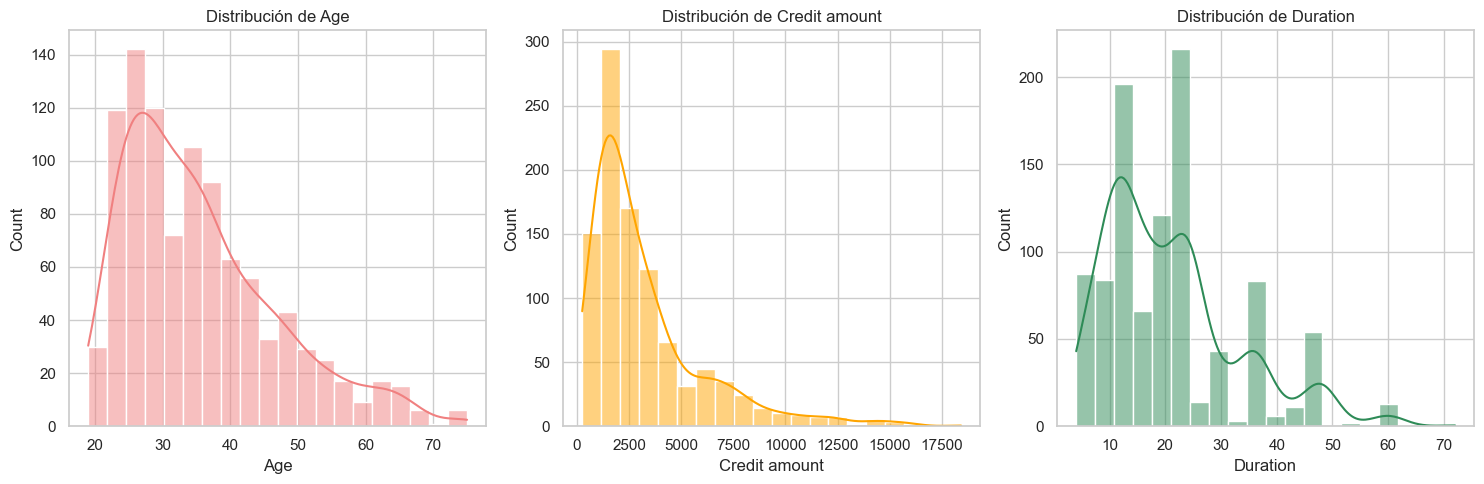

In [9]:
# Identifica las columnas numéricas en el DataFrame y las almacena en la lista 'num_vars'.
num_vars = ['Age', 'Credit amount', 'Duration']

# 1. Histogramas de distribución
plt.figure(figsize=(15, 5))
pastel_palette = sns.color_palette(
    ["#F08080", "#FFA500", "#2E8B57"]
)  # lightcoral, orange, green

for i, col in enumerate(num_vars):
    plt.subplot(1, 3, i + 1)
    sns.histplot(
        x=data[col], kde=True, bins=20, color=pastel_palette[i % len(pastel_palette)]
    )
    plt.title(f"Distribución de {col}")

plt.tight_layout()
plt.show()

- Edad: Predominan clientes de 20–40 años; pocos en edades avanzadas.

- Monto del crédito: La mayoría se concentra entre 500 y 5.000; los montos altos son poco frecuentes.

- Duración: Generalmente menor a 24 meses; los plazos largos tienden a asociarse a montos mayores.

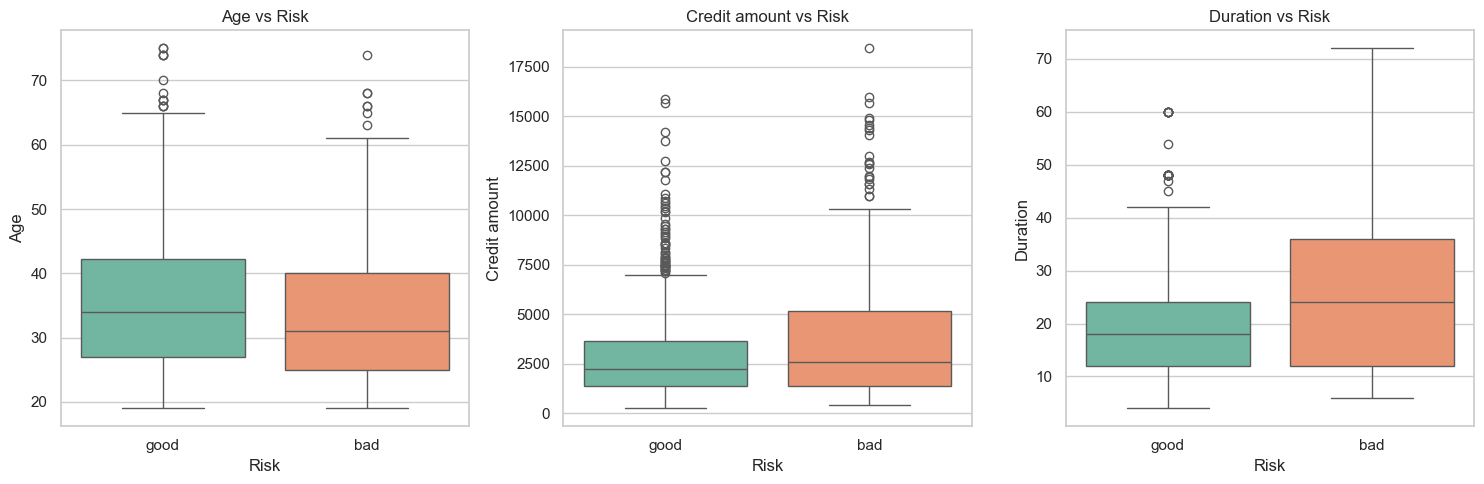

In [10]:
import warnings

# 2. Boxplots para ver la relación con el Riesgo
warnings.filterwarnings("ignore", category=FutureWarning)

plt.figure(figsize=(15, 5))
for i, col in enumerate(num_vars):
    plt.subplot(1, 3, i + 1)
    sns.boxplot(x="Risk", y=col, data=data, palette="Set2", hue="Risk", legend=False)
    plt.title(f"{col} vs Risk")
plt.tight_layout()
plt.show()

warnings.filterwarnings("default", category=FutureWarning)

- **Perfil típico:** Clientes de 30–40 años, con créditos de 2k–4k y plazos de 12–24 meses.

- **Outliers:**

  - Edad: pocos.

  - Duración: pocos.

  - Monto de crédito: muchos y muy altos → distribución con cola larga y alta dispersión.

- **Implicación para modelos:** Conviene aplicar normalización, transformaciones logarítmicas y/o tratamiento de outliers en Credit Amount para mejorar estabilidad y desempeño.

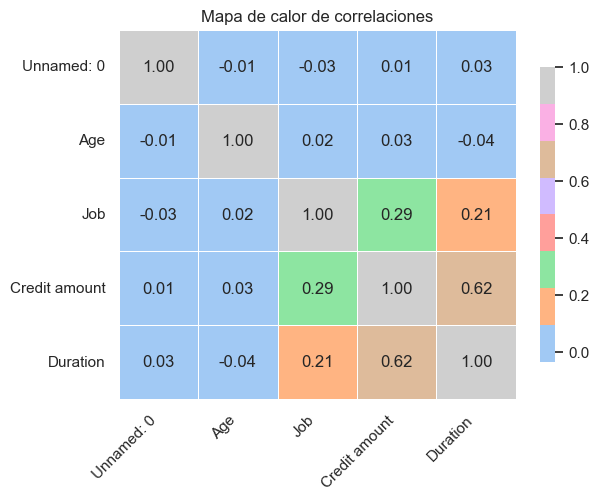

In [11]:
# Mapa para visualizar las correlaciones entre las variables numéricas, facilitando la identificación de relaciones entre ellas.
pastel_colors = sns.color_palette("pastel", 8)
cmap = sns.color_palette(pastel_colors, as_cmap=True)

corr = data.corr(numeric_only=True)

sns.heatmap(
    corr, annot=True, cmap=cmap, fmt=".2f", linewidths=0.5, cbar_kws={"shrink": 0.8}
)

plt.title("Mapa de calor de correlaciones", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.show()

**Conclusiones Generales:** El monto de crédito y duración de préstamo estan fuertemente relacionados. La edad no influye en nunguna variable y el tipo de trabajo tiene una relacion leve con el monto de crédito solicitado.

In [12]:
# Filtra el DataFrame 'data' para incluir solo las filas donde la columna 'Duration' tiene un valor mayor o igual a 60, 
# lo que permite analizar solo los casos con una duración de crédito de al menos 60 meses.
data.query("Duration >= 60")

,Unnamed: 0,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
29,29,63,male,2,own,little,little,6836,60,business,bad
134,134,21,female,2,own,moderate,NaN,10144,60,radio/TV,good
255,255,27,male,1,own,NaN,moderate,7418,60,radio/TV,good
332,332,24,female,3,own,moderate,moderate,7408,60,car,bad
373,373,63,male,3,free,NaN,NaN,13756,60,car,good
374,374,60,female,3,free,moderate,moderate,14782,60,vacation/others,bad
616,616,27,male,3,free,NaN,moderate,9157,60,radio/TV,good
637,637,21,male,2,own,little,NaN,15653,60,radio/TV,good
672,672,42,male,3,own,little,NaN,10366,60,car,good
677,677,24,male,2,own,moderate,moderate,5595,72,radio/TV,bad


In [27]:
# Define una lista de nombres de columnas que contienen variables categóricas.
categorical_cols = [
    "Sex",
    "Job",
    "Housing",
    "Saving account",
    "Checking account",
    "Purpose",
]

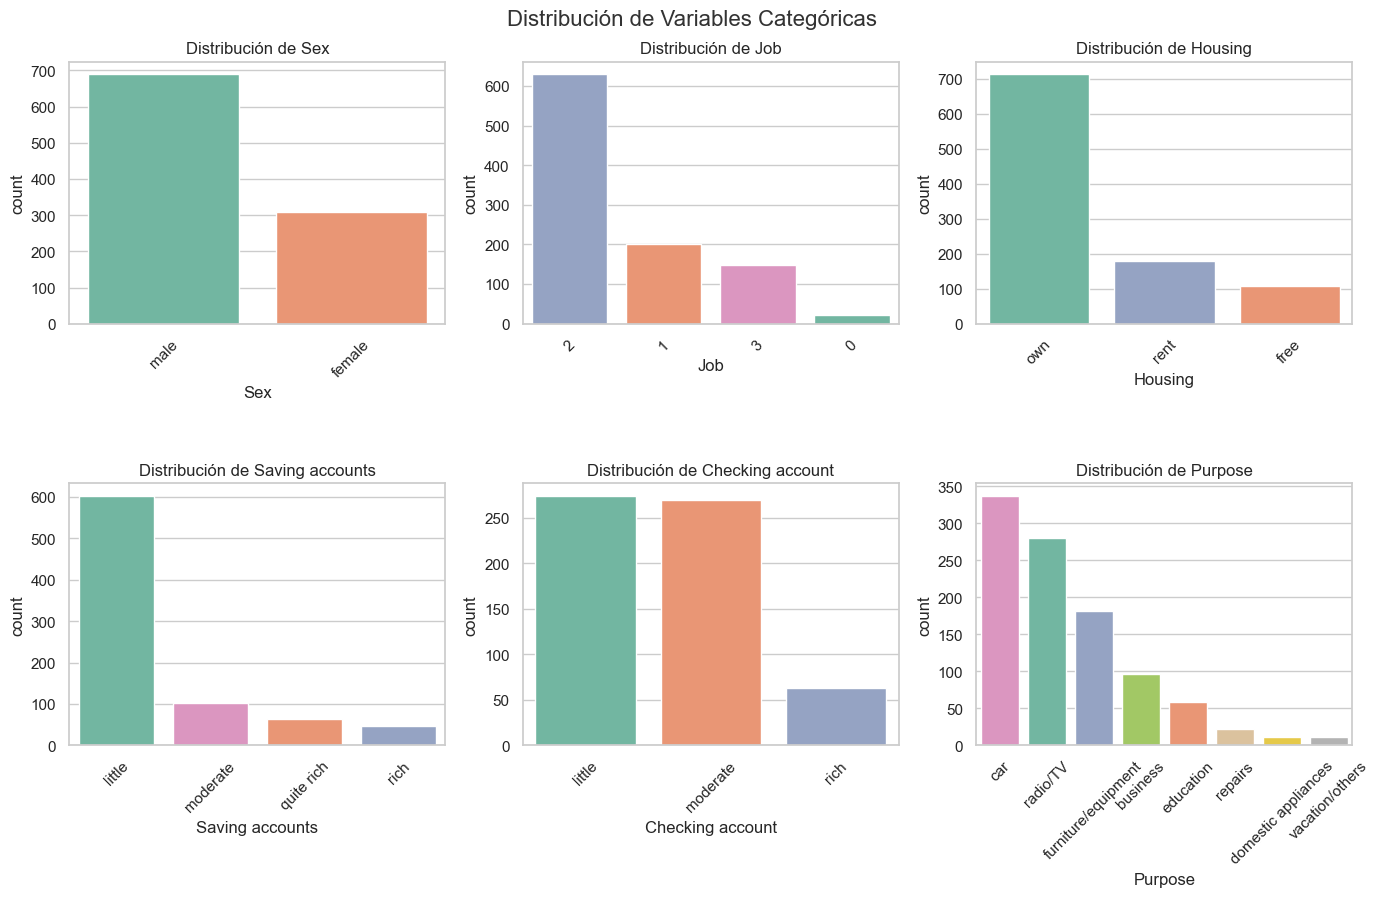

In [14]:
# Visualizar la distribución de cada variable categórica, mostrando la frecuencia de cada categoría.
plt.figure(figsize=(14, 12))
for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(
        data=data,
        x=col,
        palette="Set2",
        order=data[col].value_counts().index,
        hue=col,
        legend=False,
    )
    plt.title(f"Distribución de {col}")
    plt.xticks(rotation=45)

plt.suptitle("Distribución de Variables Categóricas", fontsize=16, color="#333333")
plt.tight_layout()
plt.show()

- Sexo: Predominan hombres (~690) sobre mujeres (~310), más del doble → posible sesgo en modelos.

- Nivel laboral (Job): Mayoría en nivel intermedio (Job 2 ≈ 600); extremos (0 y 3) escasos → riesgo de aprendizaje limitado para estos grupos.

- Vivienda (Housing): Predomina propiedad propia (~700), alquiler (~200), gratuita (~100) → estabilidad financiera concentrada, subrepresentación de “rent” y “free” puede afectar predicciones.

- Perfil típico del cliente: Hombre, nivel laboral 2, dueño de vivienda, poco ahorro, cuenta corriente pequeña o moderada, solicita crédito para automóvil o electrodomésticos.

Monto promedio de crédito por nivel de trabajo:
   Job  Credit amount
0    0    2745.136364
1    1    2358.520000
2    2    3070.965079
3    3    5435.493243


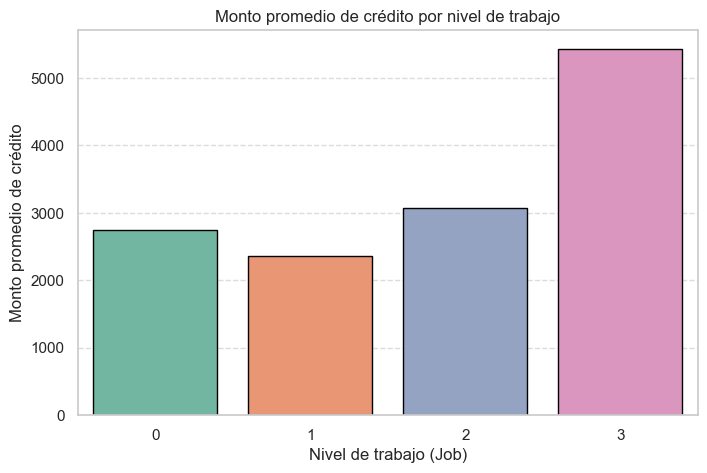

In [25]:
# Calcular monto promedio por nivel de trabajo
promedios = data.groupby("Job")["Credit amount"].mean().reset_index()

print("Monto promedio de crédito por nivel de trabajo:")
print(promedios)

# Gráfico de barras usando palette correctamente
plt.figure(figsize=(8, 5))
sns.barplot(
    x="Job",
    y="Credit amount",
    hue="Job",  # asignar x a hue
    data=promedios,
    palette="Set2",
    edgecolor="black",
    dodge=False,  # evita separar barras
    legend=False,  # desactiva leyenda
)
plt.title("Monto promedio de crédito por nivel de trabajo")
plt.xlabel("Nivel de trabajo (Job)")
plt.ylabel("Monto promedio de crédito")
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.show()

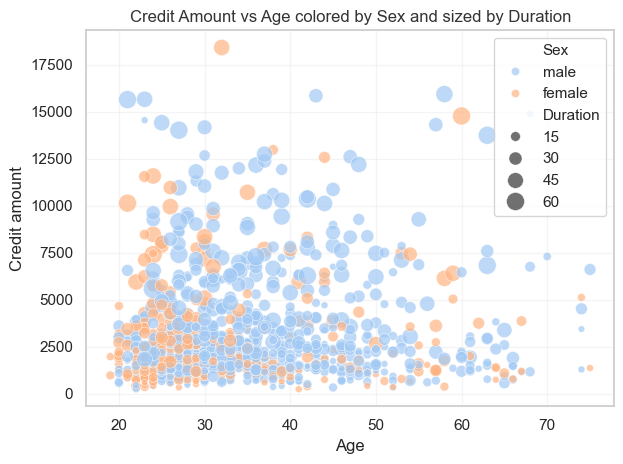

In [16]:
# El gráfico de dispersión muestra la relación entre la edad y el monto del crédito.
sns.scatterplot(
    data=data,
    x="Age",
    y="Credit amount",
    hue="Sex",
    size="Duration",
    sizes=(20, 200),
    alpha=0.7,
    palette="pastel",
)

plt.title(
    "Credit Amount vs Age colored by Sex and sized by Duration",
    fontsize=12,
    color="#333333",
)
plt.xlabel("Age")
plt.ylabel("Credit amount")
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()

El gráfico muestra que:

- El monto del crédito aumenta ligeramente con la edad, hasta un punto.

- Hombres y mujeres se comportan de manera parecida en montos y duraciones.

- Los créditos grandes requieren más meses, independientemente del sexo.

El segmento clave que solicita créditos es el de 20 a 50 años.

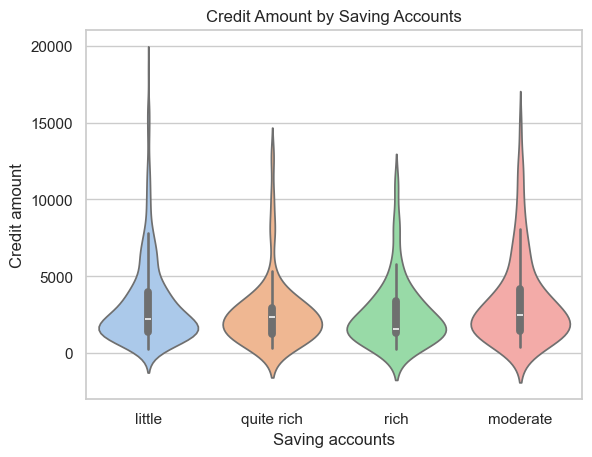

In [17]:
# Credit Amount (monto del crédito) en relación con las Saving accounts (cuentas de ahorro).
sns.violinplot(
    data=data,
    x="Saving accounts",
    y="Credit amount",
    hue="Saving accounts",
    legend=False,
    palette="pastel",
)
plt.title("Credit Amount by Saving Accounts")
plt.show()

Explicación del gráfico

No hay una gran diferencia en el monto típico del crédito entre los grupos de ahorro. Todos los grupos piden mayormente créditos entre 1000 y 3000.

- El grupo ‘little’ es el más numeroso y también el que presenta la mayor diversidad de montos, incluyendo muchos casos extremos altos.

- Tener más ahorros no implica pedir créditos más altos o más bajos. La distribución es muy parecida entre categorías.

- Los créditos muy grandes (10,000 a 20,000) aparecen en todos los grupos, pero son más frecuentes en personas con little y moderate.

C:\Users\anama\AppData\Local\Temp\ipykernel_8792\584580576.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")


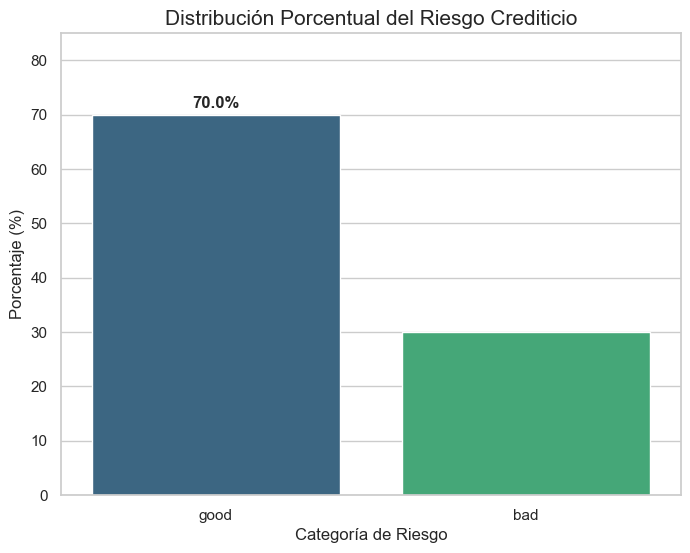

In [18]:
# 1. Calculamos la proporción
counts = data["Risk"].value_counts(normalize=True) * 100

plt.figure(figsize=(8, 6))
ax = sns.barplot(x=counts.index, y=counts.values, palette="viridis")

# 2. "Casteamos" el contenedor para que Pylance no se queje
# Le aseguramos que el primer contenedor es un BarContainer
bar_container = cast(mcontainer.BarContainer, ax.containers[0])

# 3. Ahora bar_label recibirá el tipo exacto que espera
ax.bar_label(bar_container, fmt="%.1f%%", padding=3, fontsize=12, fontweight="bold")

plt.title("Distribución Porcentual del Riesgo Crediticio", fontsize=15)
plt.ylabel("Porcentaje (%)")
plt.xlabel("Categoría de Riesgo")
plt.ylim(0, counts.max() + 15)
plt.show()

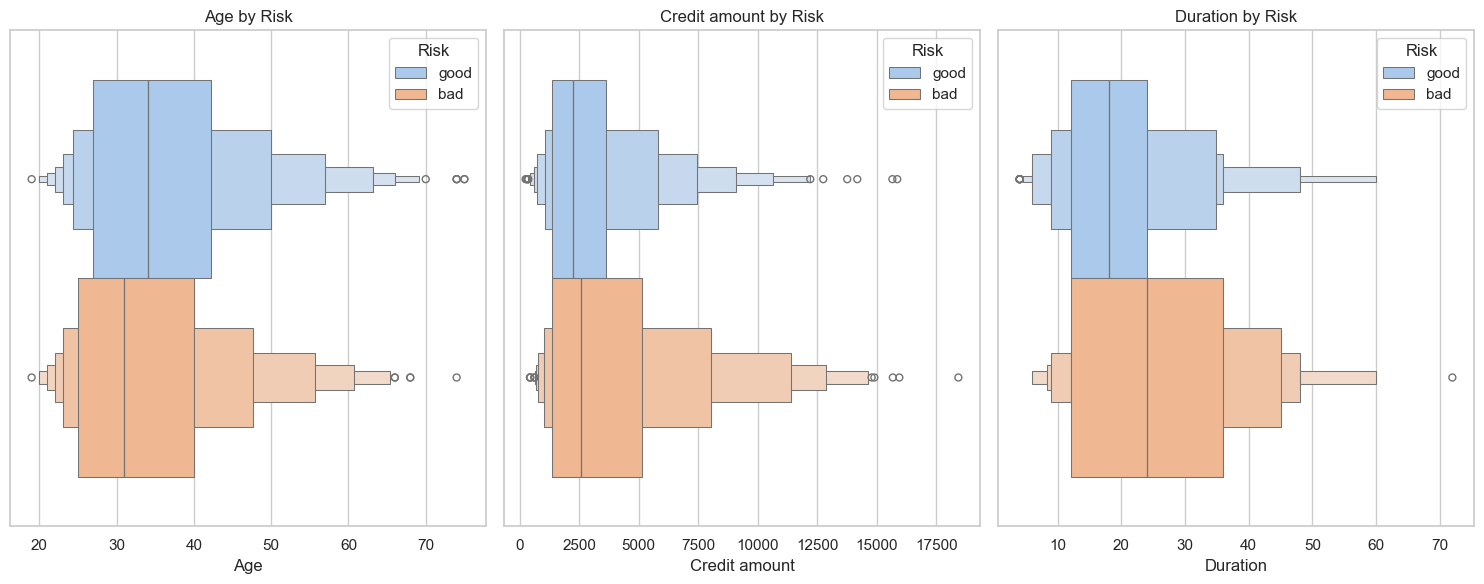

In [19]:
# El gráficos boxenplot se utiliza para visualizar la distribución de las variables numéricas
# 'Age', 'Credit amount' y 'Duration' en relación con la variable 'Risk'.
# Esto permite comparar cómo se distribuyen estas variables para créditos 'good' y 'bad'.
plt.figure(figsize=(15, 6))
for i, col in enumerate(["Age", "Credit amount", "Duration"]):
    plt.subplot(1, 3, i + 1)
    sns.boxenplot(data=data, x=col, hue="Risk", palette="pastel")
    plt.title(f"{col} by Risk")

plt.tight_layout()
plt.show()

- **Edad por Riesgo:**

  - **Riesgo Bueno:** mayoría entre 30–40 años, frecuencia decrece hacia edades menores y mayores.

  - **Riesgo Malo:** también centrado en 30–40 años, pero con colas hacia jóvenes (<25) y mayores (hasta 60).

- **Monto del Crédito por Riesgo:**

  - **Riesgo Bueno:** concentrado en montos bajos (<2,500–3,000), distribución sesgada a la derecha.

  - **Riesgo Malo:** similar en montos bajos, pero mayor proporción de créditos altos (cola hasta ~15,000).

- **Duración del Crédito por Riesgo:**

  - **Riesgo Bueno:** duración corta, 12–24 meses, frecuencia disminuye rápidamente en plazos largos.

  - **Riesgo Malo:**  distribución más dispersa, créditos largos asociados con riesgo alto; créditos cortos predominan en riesgo bueno.

**Resumen:** los créditos de mayor monto y mayor duración tienden a clasificarse como riesgo malo, mientras que edades centradas en 30–40 años predominan en ambos grupos.

In [20]:
categorical_cols

['Sex', 'Job', 'Housing', 'Saving accounts', 'Checking account', 'Purpose']

In [21]:
data.groupby("Risk")[["Age", "Credit amount", "Duration"]].mean()

,Age,Credit amount,Duration
Risk,,,
bad,33.963333,3938.126667,24.860000
good,36.224286,2985.457143,19.207143


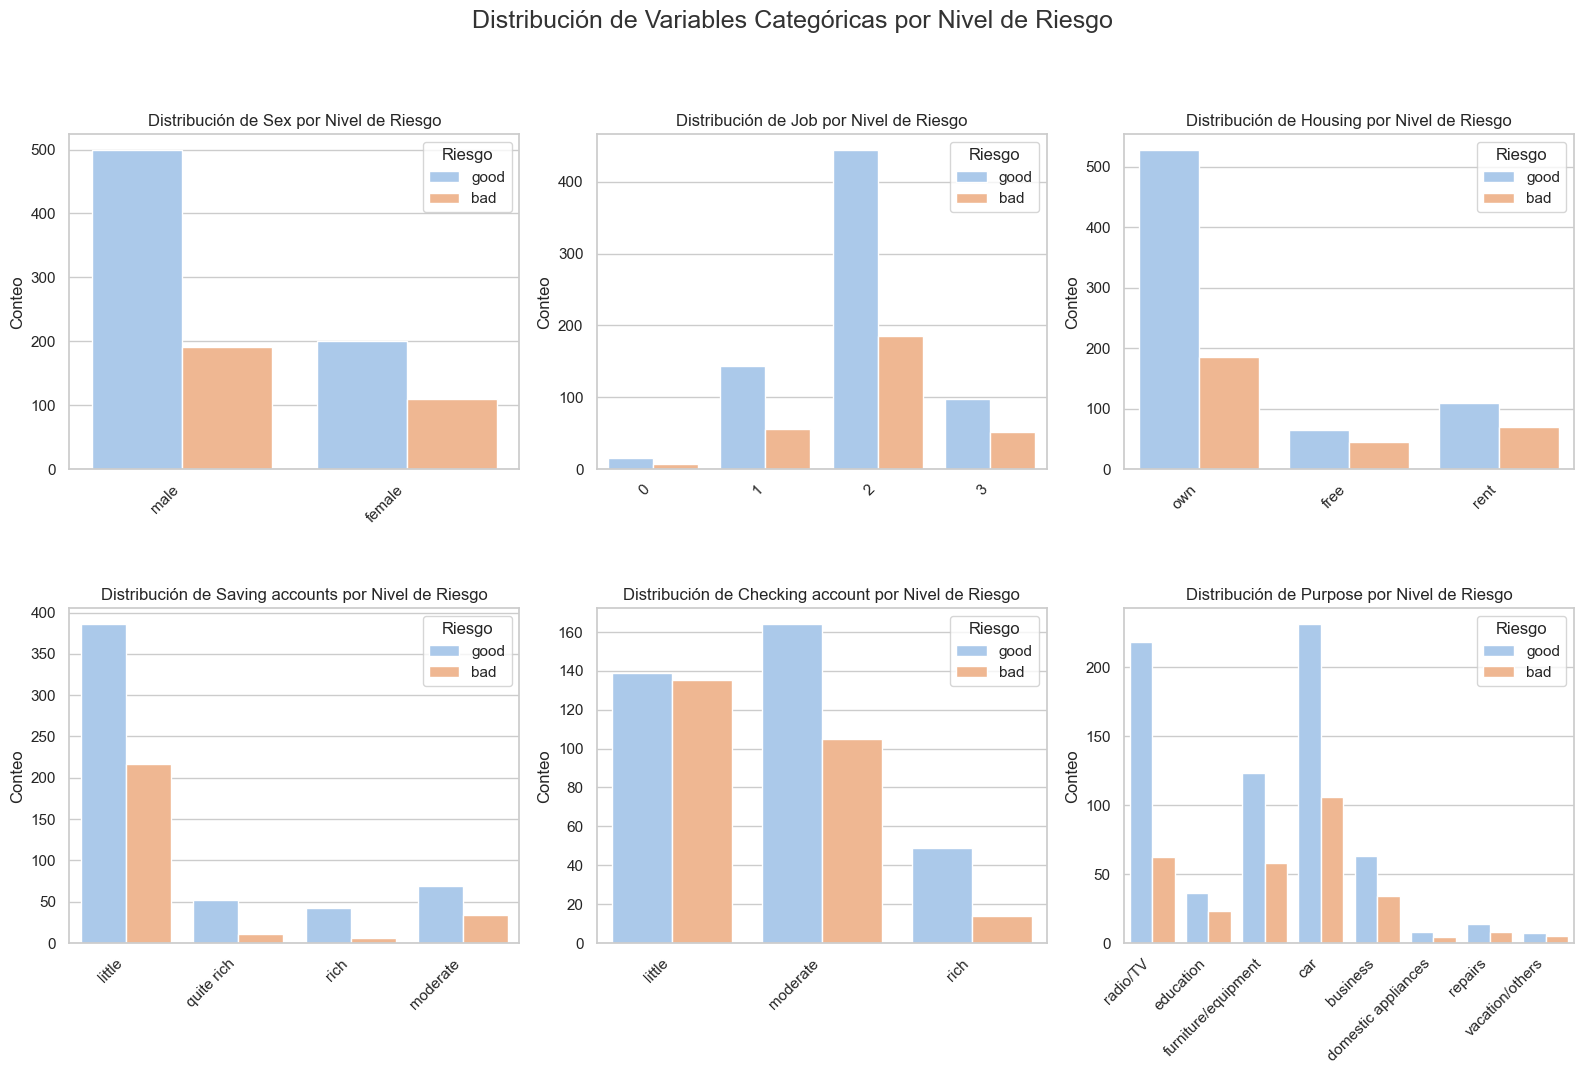

In [22]:
# El gráfico de barras muestra la distribución de cada variable categórica en función del nivel de riesgo ('Risk'), 
# permitiendo comparar visualmente cómo se distribuyen las categorías para créditos 'good' y 'bad'.
plt.figure(figsize=(16, 15))

for i, col in enumerate(categorical_cols):
    plt.subplot(3, 3, i + 1)
    sns.countplot(data=data, x=col, hue="Risk", palette="pastel")
    plt.title(f"Distribución de {col} por Nivel de Riesgo", fontsize=12)
    plt.xticks(rotation=45, ha="right")
    plt.xlabel("")
    plt.ylabel("Conteo")
    plt.legend(title="Riesgo")

plt.suptitle(
    "Distribución de Variables Categóricas por Nivel de Riesgo",
    fontsize=18,
    color="#333333",
)

# Corrección: Cambiamos la lista [] por una tupla ()
plt.tight_layout(rect=(0, 0.03, 1, 0.95))
plt.show()

Esta serie de gráficos de barras para cada variable categórica, muestra la distribución de sus categorías y diferenciando por el nivel de riesgo ('Risk'). Esto permite visualizar cómo cada categoría se divide entre créditos 'Good' y 'Bad', ayudando a identificar patrones de riesgo.

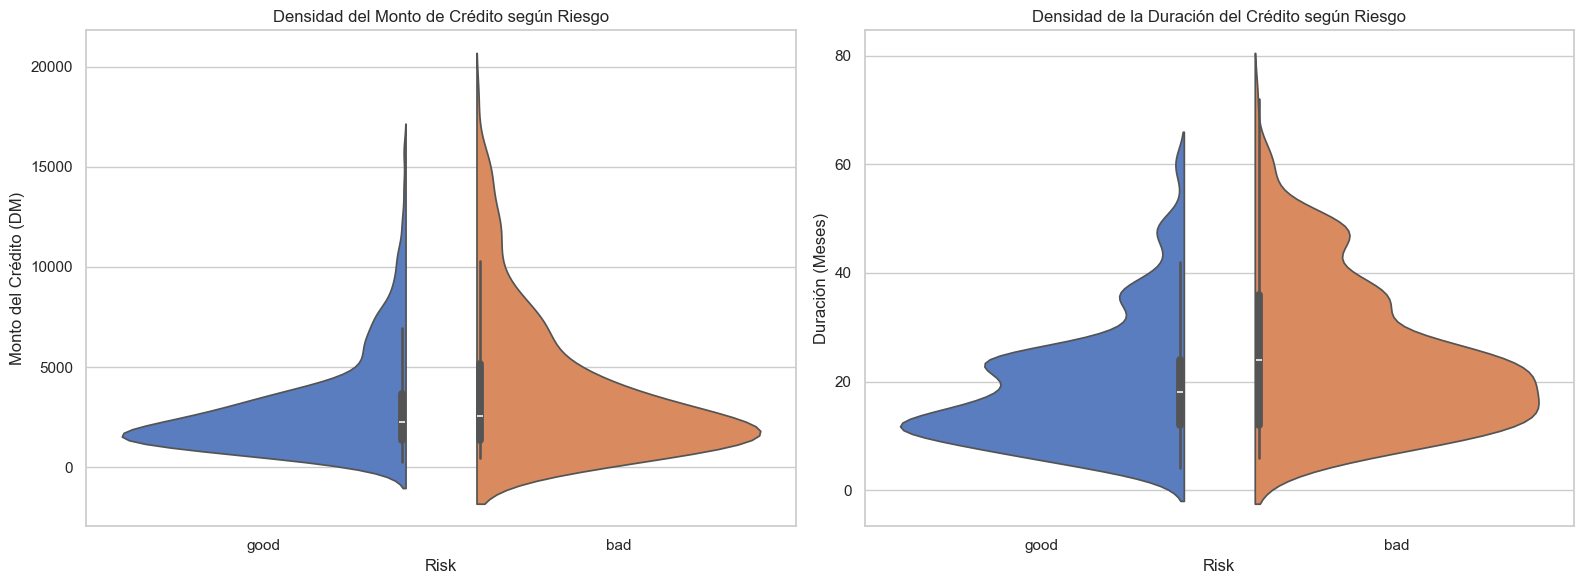

In [23]:
# El gráfico de violín muestra la distribución de las variables 'Credit amount' y 'Duration' en función del nivel de riesgo ('Risk'),
# permitiendo comparar visualmente cómo se distribuyen estas variables para créditos 'good' y 'bad'.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Monto del Crédito vs Riesgo
sns.violinplot(
    ax=axes[0],
    x="Risk",
    y="Credit amount",
    data=data,
    palette="muted",
    split=True,
    hue="Risk",
    legend=False,
)
axes[0].set_title("Densidad del Monto de Crédito según Riesgo")
axes[0].set_ylabel("Monto del Crédito (DM)")

# 2. Duración vs Riesgo
sns.violinplot(
    ax=axes[1],
    x="Risk",
    y="Duration",
    data=data,
    palette="muted",
    split=True,
    hue="Risk",
    legend=False,
)
axes[1].set_title("Densidad de la Duración del Crédito según Riesgo")
axes[1].set_ylabel("Duración (Meses)")

plt.tight_layout()
plt.show()

warnings.filterwarnings("default", category=FutureWarning)

- Distribución de Riesgo: 700 casos good vs 300 bad → clase good domina más del doble.

- Implicación: dataset desbalanceado; la clase minoritaria (bad) podría aprenderse mal.

- Recomendaciones para ML: aplicar técnicas de balanceo como oversampling (SMOTE), undersampling o ajuste de pesos de clase.